In [1]:
# import labraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm


In [6]:
plt.style.use("seaborn-v0_8")
np.random.seed(42)

In [20]:
# download NIFTY 50 data
ticker="^NSEI"
data=yf.download(ticker, start="2018-01-01", end="2024-01-01",auto_adjust=True)

prices=data["Close"].dropna()

#Log returns
returns=np.log(prices/prices.shift(1).dropna())

df=pd.DataFrame()
df["returns"]=returns
df.head()

[*********************100%***********************]  1 of 1 completed


,returns
Date,
2018-01-02,NaN
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114


In [34]:
df=df.dropna()
df.head()


,returns
Date,
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114
2018-01-09,0.001261


In [36]:
# outcome
df["Y_return"]=df["returns"]

In [42]:
#rolling volatitily (20-day)
df["vol_20"]=df["returns"].rolling(20).std()

# treatment: volatility shock(top 25%)
threshold=df["vol_20"].quantile(0.75)
df["T_vol_shock"]=(df["vol_20"]>threshold).astype(int)

#confounder
df["lag_return"]=df["returns"].shift(1)

df=df.dropna()
df.head()

,returns,Y_return,vol-20,vol_20,T_vol_shock,lag_return
Date,,,,,,
2018-01-31,-0.001988,-0.001988,0.004471,0.004471,0,-0.007281
2018-02-01,-0.000980,-0.000980,0.004510,0.004510,0,-0.001988
2018-02-02,-0.023539,-0.023539,0.007327,0.007327,0,-0.000980
2018-02-05,-0.008779,-0.008779,0.007590,0.007590,0,-0.023539
2018-02-06,-0.015904,-0.015904,0.008298,0.008298,0,-0.008779


In [44]:
df[["Y_return","vol_20","T_vol_shock","lag_return"]].describe()

,Y_return,vol_20,T_vol_shock,lag_return
count,1457.000000,1457.000000,1457.000000,1457.000000
mean,0.000464,0.009629,0.249828,0.000461
std,0.011629,0.006417,0.433062,0.011630
min,-0.139038,0.003396,0.000000,-0.139038
25%,-0.004805,0.006191,0.000000,-0.004805
50%,0.000892,0.007958,0.000000,0.000892
75%,0.006671,0.010906,0.000000,0.006671
max,0.084003,0.057000,1.000000,0.084003


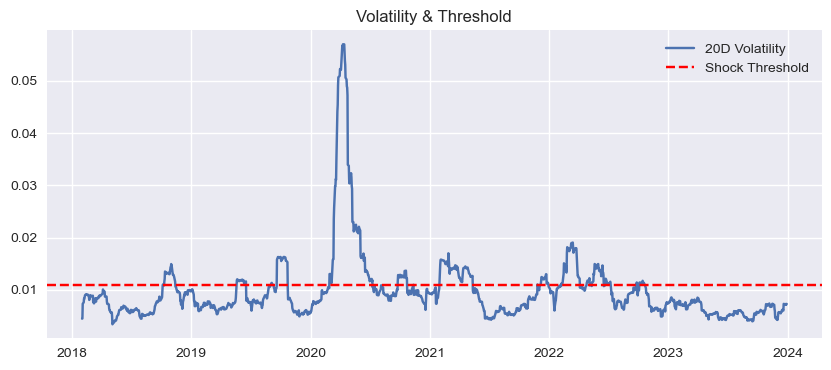

In [48]:
# simple visualization
plt.figure(figsize=(10,4))
plt.plot(df.index,df["vol_20"],label="20D Volatility")
plt.axhline(threshold,color="red",linestyle="--",label="Shock Threshold")
plt.legend()
plt.title("Volatility & Threshold")
plt.show()

In [58]:
#Treatment effect = coeffient of T_vol_shock
X=df[["T_vol_shock","lag_return"]]
X=sm.add_constant(X)
y=df["Y_return"]

model=sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Y_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.262
Date:                Fri, 09 Jan 2026   Prob (F-statistic):              0.283
Time:                        14:53:33   Log-Likelihood:                 4424.2
No. Observations:                1457   AIC:                            -8842.
Df Residuals:                    1454   BIC:                            -8827.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0005      0.000      1.430      

In [60]:
X_alt=df[["vol_20","lag_return"]]
X_alt=sm.add_constant(X_alt)

model_alt=sm.OLS(y,X_alt).fit()
print(model_alt.summary())

                            OLS Regression Results                            
Dep. Variable:               Y_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.285
Date:                Fri, 09 Jan 2026   Prob (F-statistic):              0.277
Time:                        14:56:15   Log-Likelihood:                 4424.3
No. Observations:                1457   AIC:                            -8843.
Df Residuals:                    1454   BIC:                            -8827.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.001      0.677      0.4

In [62]:
corr=df[["T_vol_shock","Y_return","vol_20","lag_return"]].corr()
corr

,T_vol_shock,Y_return,vol_20,lag_return
T_vol_shock,1.000000,-0.002943,0.635077,0.000145
Y_return,-0.002943,1.000000,0.006297,-0.041523
vol_20,0.635077,0.006297,1.000000,0.002068
lag_return,0.000145,-0.041523,0.002068,1.000000


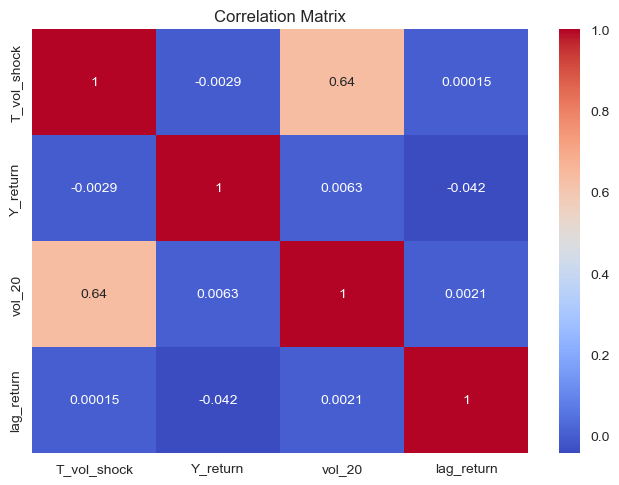

In [64]:
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

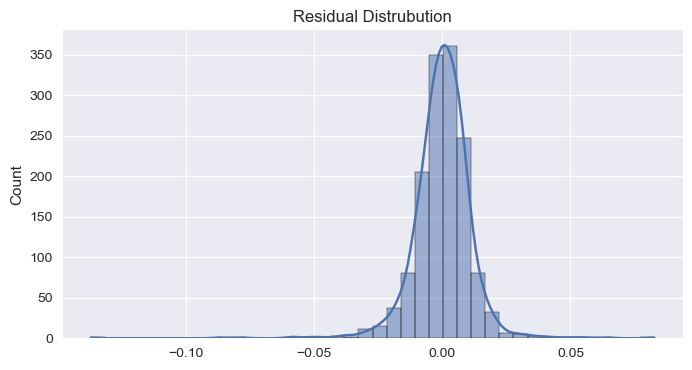

In [66]:
# residuals check
resid=model.resid
plt.figure(figsize=(8,4))
sns.histplot(resid,bins=40,kde=True)
plt.title("Residual Distrubution")
plt.show()

In [ ]:
data.to_csv()